# <a id='toc1_'></a>[Frozen Lake](#toc0_)

### <a id='toc1_1_1_'></a>[Описание задачи](#toc0_)

**Характеристики игры**  
* Эпизодическая среда
* Стохастическая / Детерминированная среда
* Дискретная среда
* Среда с полной информацией

**Цель игры**  
Необходимо перейти из начального состояния **S** в целевое состояние **G**,<br> пройдя только по льду **F** и избегая полыньи **H**.<br>
Однако лед скользкий, поэтому вы не всегда будете двигаться в нужном направлении.

**Окружение**

<img src="http://simoninithomas.com/drlc/Qlearning/frozenlake4x4.png" />

**Пространство действий**

* Пойти направо
* Пойти налево
* Пойти вверх
* Пойти вниз

**Терминальные состояния**  
Эпизод заканчивается, когда вы достигаете цели или попадаете в полынью.

**Функция вознаграждения**  
Вы получаете вознаграждение в размере 1, если вы достигнете цели, и ноль в противном случае.

**Полезные ссылки**
* https://gymnasium.farama.org/environments/toy_text/frozen_lake
* https://gymnasium.farama.org/tutorials/training_agents/FrozenLake_tuto




***

### <a id='toc1_1_2_'></a>[Установка зависимостей, импорт библиотек](#toc0_)

**Установка зависимостей**

In [44]:
#!pip install gymnasium

**Импорт библиотек**

In [45]:
import os
import sys
import PIL
import time
import json
import random
import numpy as np
import pandas as pd
import shutil as sh
from glob import glob
from pytz import timezone
from datetime import datetime
#from google.colab import drive
from collections import deque
from base64 import b64encode
from matplotlib import pyplot as plt
from IPython.display import display, clear_output, HTML
import seaborn as sns

In [46]:
import gymnasium as gym

### <a id='toc1_1_3_'></a>[Выбор временной зоны](#toc0_)

In [47]:
TZ = timezone('Europe/Moscow')

### <a id='toc1_1_4_'></a>[Определение путей и директорий](#toc0_)

In [48]:
env_dir = '.'
scenarios_dir = os.path.join(env_dir, 'scenarios')

In [49]:
if not os.path.exists(scenarios_dir):
    os.makedirs(scenarios_dir)

### <a id='toc1_1_5_'></a>[Вспомогательные методы](#toc0_)

**Отображение состояния среды, сохранение записи эпизода, просмотр записи эпизода**

In [50]:
def display_state(state):
    plt.figure(figsize=(6, 6))
    plt.imshow(state)
    plt.axis('off')


def record_episode(eps_frames, records_dir, agent_name, exp_id, eps_num):
    record_path = os.path.join(records_dir, f'{agent_name}_{exp_id}_eps-{eps_num}.mp4')
    eps_frame_dir = 'episode_frames'
    os.mkdir(eps_frame_dir)

    for i, frame  in enumerate(eps_frames):
        PIL.Image.fromarray(frame).save(os.path.join(eps_frame_dir, f'frame-{i+1}.png'))

    os.system(f'ffmpeg -r 2 -i {eps_frame_dir}/frame-%1d.png -vcodec libx264 -b 10M -y "{record_path}"');
    sh.rmtree(eps_frame_dir)


def show_episode_records(records_dir):
    record_paths = glob(os.path.join(records_dir, "*.mp4"))
    html_str = ''
    for i, record_path in enumerate(record_paths):
        mp4 = open(record_path, 'rb').read()
        data = f"data:video/mp4;base64,{b64encode(mp4).decode()}"
        html_str += f'EPISODE # {i+1}<br><video width=500 controls><source src="{data}" type="video/mp4"></video><br><br>'
    return HTML(html_str)


**Создание директорий для логирования результатов, сохрание параметров и метрик экспериментов**

In [51]:
def create_exp_dirs(scenarios_dir, exp_params):
    dirs = dict()
    dirs['exp'] = os.path.join(scenarios_dir, exp_params["scenario_name"], exp_params["algorithm_name"], exp_params["exp_id"])
    dirs['training'] = os.path.join(dirs['exp'], 'training')
    dirs['evaluation'] = os.path.join(dirs['exp'], 'evaluation')
    os.makedirs(dirs['training'], exist_ok=True)
    os.makedirs(dirs['evaluation'], exist_ok=True)
    return dirs


def save_exp_params(params, exp_dir):
    params_path = os.path.join(exp_dir, 'experiment_params.json')
    with open(params_path, 'w') as f:
        json.dump(params, f)


def save_metrics(metrics, metrics_type, train_eps_dir):
    metrics_path = os.path.join(train_eps_dir, f'{metrics_type}_metrics.json')
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f)

**Построение графика процесса валидации для выбранных экспериментов**

In [52]:
def display_validation_plot(scenarios_dir, scenario_name, exp_ids):
    fig = plt.figure(figsize=(10, 6))
    earliest_validation_eps = np.inf
    max_training_eps_count = 0

    for model_name in exp_ids.keys():
        for exp_id in exp_ids[model_name]:
            exp_dir = os.path.join(scenarios_dir, scenario_name, model_name, exp_id)
            exp_params_path = os.path.join(exp_dir, 'experiment_params.json')
            training_dir = os.path.join(exp_dir, 'training')

            with open(exp_params_path, 'r') as f:
                exp_params = json.load(f)
            total_eps_count = exp_params['training']['episode_count']
            validation_step = exp_params['validation']['validate_agent_every_n_eps']
            if total_eps_count > max_training_eps_count:
                max_training_eps_count = total_eps_count
            if validation_step < earliest_validation_eps:
                earliest_validation_eps = validation_step

            exp_win_shares = list()
            for iter_name in os.listdir(training_dir):
                iter_metrics_path = os.path.join(training_dir, iter_name, 'training_iter_metrics.json')
                with open(iter_metrics_path, 'r') as f:
                    iter_metrics = json.load(f)
                exp_win_shares.append(iter_metrics['win_share'])

            iter_means = np.mean(exp_win_shares, axis=0).round(3)
            iter_stds = np.std(exp_win_shares, axis=0).round(3)
            std_bounds = np.array([[avg - std, avg + std] for avg, std in list(zip(iter_means, iter_stds))])
            validation_steps = range(validation_step, total_eps_count + validation_step, validation_step)

            plt.plot(validation_steps, iter_means, label=f'{model_name} ({exp_id})')
            plt.fill_between(validation_steps, std_bounds[:,0], std_bounds[:,1], alpha=.3)

    plt.xlim(earliest_validation_eps, max_training_eps_count)
    plt.ylim(0, 1)
    plt.xlabel('Training episodes')
    plt.ylabel('Win share')
    plt.title(f'Сomparative assessment of learning process ({scenario_name})')
    plt.legend(loc='upper left')
    plt.grid()

**Загрузка лучшего агента из всех итераций для выбранного шага обучения**

In [53]:
def load_best_agent_for_train_step(train_eps_num, iteration_count, training_dir, agent):
    best_iter_num = 1
    best_win_share = 0
    best_avg_step_count = 100
    for iter_num in range(1, iteration_count+1):
        iter_dir = os.path.join(training_dir, f'iter-{iter_num}')
        eps_dir = os.path.join(iter_dir, f'eps-{train_eps_num}')
        val_metrics_path = os.path.join(eps_dir, 'validation_metrics.json')
        with open(val_metrics_path, 'r') as f:
            val_metrics = json.load(f)
        if val_metrics['win_share'] > best_win_share and val_metrics['avg_step_count'] < best_avg_step_count:
            best_iter_num = iter_num
            best_win_share = val_metrics['win_share']
            best_avg_step_count = val_metrics['avg_step_count']

    agent_state_dir = os.path.join(training_dir, f'iter-{best_iter_num}', f'eps-{train_eps_num}')
    agent.load_agent_state(agent_state_dir)

## <a id='toc1_2_'></a>[Обзор окружения](#toc0_)

In [54]:
MAP_SIZE = 8
STOCHASTIC_ENV = True
ACTION_MAP = {
    'L': 0,
    'D': 1,
    'R': 2,
    'U': 3
}

def create_environment(map_size, stochastic_env):
    return gym.make('FrozenLake-v1', map_name=f'{map_size}x{map_size}', is_slippery=stochastic_env, render_mode='rgb_array')


### <a id='toc1_2_1_'></a>[Создание окружения, старт нового эпизода, отображение начального состояния](#toc0_)

Current state: 0


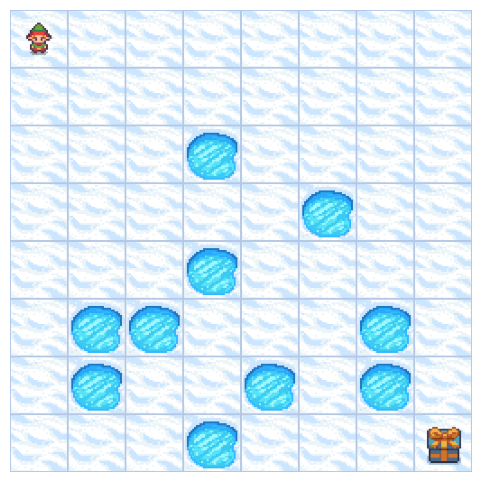

In [55]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)
state, info = env.reset()
state_rgb = env.render()

print(f'Current state: {state}')
display_state(state_rgb)

### <a id='toc1_2_2_'></a>[Тестирование окружения](#toc0_)

Current state: 8
Reward: 0.0
Done: (False, False)


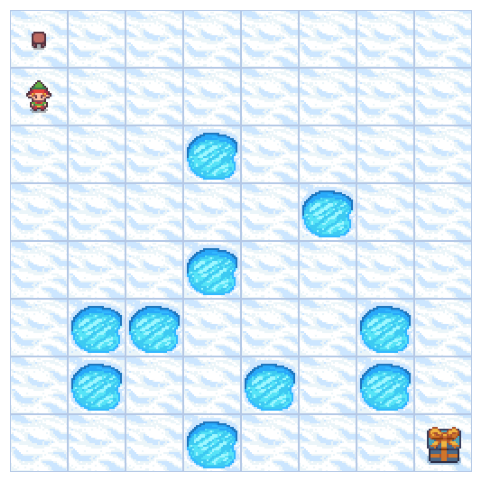

In [56]:
action_name = 'D'
action = ACTION_MAP[action_name]

next_state, reward, terminated, truncated, info = env.step(action)
next_state_rgb = env.render()

print(f'Current state: {next_state}\nReward: {reward}\nDone: {terminated, truncated}')
display_state(next_state_rgb)

In [57]:
env.close()

## <a id='toc1_3_'></a>[Тестирование агента со случайной стратегией в стохастической среде](#toc0_)

### <a id='toc1_3_1_'></a>[Случайный агент](#toc0_)

In [58]:
class RandomAgent:

  def __init__(self, env, params):
      self._env = env
      self._params = params

  @property
  def name(self):
      return f"{self._params['algorithm_name']}_agent"

  def choose_action(self, state, mode='exploitation'):
      return self._env.action_space.sample()

### <a id='toc1_3_2_'></a>[Методы для запуска эпизодов и оценки агента](#toc0_)

In [59]:
def run_episode(env, agent):
    state, info = env.reset()
    step_count = 0
    frames = list()
    done = False

    while not done:
        action = agent.choose_action(state, mode='exploitation')
        next_state, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        done = terminated or truncated
        state = next_state
        step_count += 1

    frames.extend([env.render()] * 3)
    return state, step_count, frames


def evaluate_agent(env, agent, exp_params, exp_dirs):
    for eps_num in range(1, exp_params['evaluation']['episode_count'] + 1):
        eps_final_state, eps_step_count, eps_frames = run_episode(env, agent)
        record_episode(eps_frames, exp_dirs['evaluation'], exp_params['algorithm_name'], exp_params['exp_id'], eps_num)

        print(f'EPISODE # {eps_num}')
        if eps_final_state == env.observation_space.n - 1:
            print('Agent reached the Goal 🏆')
        else:
            print('Agent was defeated ☠️')
        print(f'Number of steps: {eps_step_count}')
        print('-' * 50)

### <a id='toc1_3_3_'></a>[Параметры эксперимента](#toc0_)

In [60]:
exp_params = {
    'scenario_name': f'{MAP_SIZE}x{MAP_SIZE}_{"stochastic" if STOCHASTIC_ENV else "deterministic"}',
    'algorithm_name': 'random',
    'exp_id': f'exp-1',
    'seed': 21,
    'evaluation': {
        'episode_count': 3
    }
}

exp_dirs = create_exp_dirs(scenarios_dir, exp_params)
save_exp_params(exp_params, exp_dirs['exp'])

### <a id='toc1_3_4_'></a>[Оценка агента](#toc0_)

In [61]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)
random_agent = RandomAgent(env, exp_params)
evaluate_agent(env, random_agent, exp_params, exp_dirs)
env.close()

EPISODE # 1
Agent was defeated ☠️
Number of steps: 15
--------------------------------------------------
EPISODE # 2
Agent was defeated ☠️
Number of steps: 18
--------------------------------------------------
EPISODE # 3
Agent was defeated ☠️
Number of steps: 17
--------------------------------------------------


In [62]:
show_episode_records(exp_dirs['evaluation'])

## <a id='toc1_4_'></a>[Тестирование Q-агента в стохастической среде](#toc0_)

In [63]:
class QAgent:

    def __init__(self, env, params):
        self._env = env
        self._params = params
        self._epsilon = params['training']['epsilon']
        self._qtable = np.zeros((env.observation_space.n, env.action_space.n))
        self._action_arrow_map = { 0: '', 1: '←', 2: '↓', 3: '→', 4: '↑' }

    @property
    def name(self):
        return f"{self._params['algorithm_name']}_agent"

    @property
    def exploration_level(self):
        return self._epsilon


    def choose_action(self, state, mode='exploitation'):
        if mode == 'exploration':
          if np.random.rand() < self._epsilon:
              return self._env.action_space.sample()

        return np.argmax(self._qtable[state, :])


    def learn(self, state, action, next_state, reward):
        target = reward + self._params['training']['gamma'] * np.max(self._qtable[next_state, :])
        self._qtable[state, action] = self._qtable[state, action] + \
                                      self._params['training']['learning_rate'] * (target - self._qtable[state, action])


    def decrease_exploration_level(self):
        if self._epsilon > self._params['training']['epsilon_min']:
            self._epsilon *= self._params['training']['epsilon_decay_rate']


    def display_q_table(self):
        self._prepare_q_table()


    def save_q_table_as_plot(self, eps_dir):
        q_table_plot = self._prepare_q_table()
        q_table_plot_path = os.path.join(eps_dir, 'qtable.png')
        q_table_plot.savefig(q_table_plot_path, bbox_inches='tight')
        plt.close(q_table_plot)


    def save_agent_state(self, eps_dir):
        qtable_path = os.path.join(eps_dir, 'qtable.npy')
        np.save(qtable_path, self._qtable)


    def load_agent_state(self, eps_dir):
        qtable_path = os.path.join(eps_dir, 'qtable.npy')
        self._qtable = np.load(qtable_path, allow_pickle=True)


    def _prepare_q_table(self):
        greedy_values = np.max(self._qtable, axis=1).reshape(MAP_SIZE, MAP_SIZE)
        greedy_actions = np.argmax(np.hstack((np.zeros((self._env.observation_space.n, 1)), self._qtable)), axis=1)
        greedy_actions_arrows = np.array(list(map(lambda x: '' if x == 0 else self._action_arrow_map[x], greedy_actions))).reshape(MAP_SIZE, MAP_SIZE)

        fig = plt.figure()
        sns.heatmap(greedy_values,
                    annot=greedy_actions_arrows,
                    annot_kws={"fontsize": 16},
                    fmt = '',
                    cmap="YlGnBu",
                    linewidths=.5)
        plt.axis('off')
        return fig


In [64]:
def train_agent(env, agent, exp_params, exp_dirs, enable_eps_recording):
    random.seed(exp_params['seed'])
    np.random.seed(exp_params['seed'])

    train_iter_count = len(os.listdir(exp_dirs['training']))
    train_iter_dir = os.path.join(exp_dirs['training'], f'iter-{train_iter_count+1}')
    os.mkdir(train_iter_dir)

    training_eps_count = exp_params['training']['episode_count']
    validate_agent_every_n_eps = exp_params['validation']['validate_agent_every_n_eps']
    validation_eps_count = exp_params['validation']['episode_count']

    train_metrics = {
        'total_eps_count': training_eps_count,
        'validation_step': validate_agent_every_n_eps,
        'win_share': []
    }

    for eps_num in range(1, training_eps_count + 1):
        state, info = env.reset()
        done = False

        while not done:
            action = agent.choose_action(state, mode='exploration')
            next_state, reward, terminated, truncated, info = env.step(action)
            agent.learn(state, action, next_state, reward)
            done = terminated or truncated
            state = next_state

        agent.decrease_exploration_level()

        if eps_num % validate_agent_every_n_eps == 0:
            eps_dir = os.path.join(train_iter_dir, f'eps-{eps_num}')
            os.mkdir(eps_dir)

            val_metrics = validate_agent(env, agent, exp_params, eps_dir, enable_eps_recording)
            train_metrics['win_share'].append(val_metrics['win_share'])
            agent.save_q_table_as_plot(eps_dir)
            agent.save_agent_state(eps_dir)

            print(f"EPISODE # {eps_num} / {training_eps_count}")
            print(f"Win share ({validation_eps_count} eps): {val_metrics['win_share']}")
            print(f"Avg step count ({validation_eps_count} eps): {val_metrics['avg_step_count']}")
            print(f"Aget exploration level (epsilon): {val_metrics['exploration_level']}")
            print('-' * 50)

    save_metrics(train_metrics, 'training_iter', train_iter_dir)
    return train_metrics


def validate_agent(env, agent, exp_params, train_eps_dir, enable_eps_recording):
    validation_eps_count = exp_params['validation']['episode_count']
    won_eps_count = 0
    eps_step_counts = list()

    for eps_num in range(1, validation_eps_count + 1):
        eps_final_state, eps_step_count, eps_frames = run_episode(env, agent)
        if eps_final_state == env.observation_space.n - 1:
            won_eps_count += 1
        eps_step_counts.append(eps_step_count)
        if enable_eps_recording:
            record_episode(eps_frames, train_eps_dir, exp_params['algorithm_name'], exp_params['exp_id'], eps_num)

    val_metrics = {
        'win_share': round(won_eps_count / validation_eps_count, 3),
        'avg_step_count': round(sum(eps_step_counts) / validation_eps_count, 3),
        'exploration_level': round(agent.exploration_level, 3)
    }

    save_metrics(val_metrics, 'validation', train_eps_dir)
    return val_metrics

### <a id='toc1_4_1_'></a>[Параметры эксперимента](#toc0_)

In [65]:
exp_params = {
    'scenario_name': f'{MAP_SIZE}x{MAP_SIZE}_{"stochastic" if STOCHASTIC_ENV else "deterministic"}',
    'algorithm_name': 'qtable',
    'exp_id': f'exp-2',
    'seed': 21,
    'training': {
        'iteration_count': 5,
        'episode_count': 5000,
        'learning_rate': 0.05,
        'gamma': 0.99,
        'epsilon': 1.0,
        'epsilon_min': 0.01,
        'epsilon_decay_rate': 0.99995
    },
    'validation': {
        'validate_agent_every_n_eps': 500,
        'episode_count': 10
    },
    'evaluation': {
        'episode_count': 3
    }
}

exp_dirs = create_exp_dirs(scenarios_dir, exp_params)
save_exp_params(exp_params, exp_dirs['exp'])

### <a id='toc1_4_2_'></a>[Обучение агента](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Frozen Lake](#toc1_)    
    - [Описание задачи](#toc1_1_1_)    
    - [Установка зависимостей, импорт библиотек](#toc1_1_2_)    
    - [Выбор временной зоны](#toc1_1_3_)    
    - [Определение путей и директорий](#toc1_1_4_)    
    - [Вспомогательные методы](#toc1_1_5_)    
  - [Обзор окружения](#toc1_2_)    
    - [Создание окружения, старт нового эпизода, отображение начального состояния](#toc1_2_1_)    
    - [Тестирование окружения](#toc1_2_2_)    
  - [Тестирование агента со случайной стратегией в стохастической среде](#toc1_3_)    
    - [Случайный агент](#toc1_3_1_)    
    - [Методы для запуска эпизодов и оценки агента](#toc1_3_2_)    
    - [Параметры эксперимента](#toc1_3_3_)    
    - [Оценка агента](#toc1_3_4_)    
  - [Тестирование Q-агента в стохастической среде](#toc1_4_)    
    - [Параметры эксперимента](#toc1_4_1_)    
    - [Обучение агента](#toc1_4_2_)    
    - [Оценка агента](#toc1_4_3_)    
  - [Тестирование DynaQ-агента в стохастической среде](#toc1_5_)    
    - [Реализация модели окружения (Домашнее задание!)](#toc1_5_1_)    
    - [Параметры эксперимента](#toc1_5_2_)    
    - [Обучение агента](#toc1_5_3_)    
    - [Оценка агента](#toc1_5_4_)    
  - [Сравнение эффективности процесса обучения](#toc1_6_)    
  - [Выводы](#toc1_7_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [66]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)

for iter_num in range(1, exp_params['training']['iteration_count']+1):
    print(f'TRAINING ITERATION # {iter_num}\n')
    qtable_agent = QAgent(env, exp_params)
    train_agent(env, qtable_agent, exp_params, exp_dirs, enable_eps_recording=True)
    if iter_num != exp_params['training']['iteration_count']:
        clear_output()

env.close()

TRAINING ITERATION # 5

EPISODE # 500 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 100.0
Aget exploration level (epsilon): 0.975
--------------------------------------------------
EPISODE # 1000 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 100.0
Aget exploration level (epsilon): 0.951
--------------------------------------------------
EPISODE # 1500 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 100.0
Aget exploration level (epsilon): 0.928
--------------------------------------------------
EPISODE # 2000 / 5000
Win share (10 eps): 0.2
Avg step count (10 eps): 43.8
Aget exploration level (epsilon): 0.905
--------------------------------------------------
EPISODE # 2500 / 5000
Win share (10 eps): 0.1
Avg step count (10 eps): 36.3
Aget exploration level (epsilon): 0.882
--------------------------------------------------
EPISODE # 3000 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 37.8
Aget exploration level (epsilon): 0.861
-----------------------

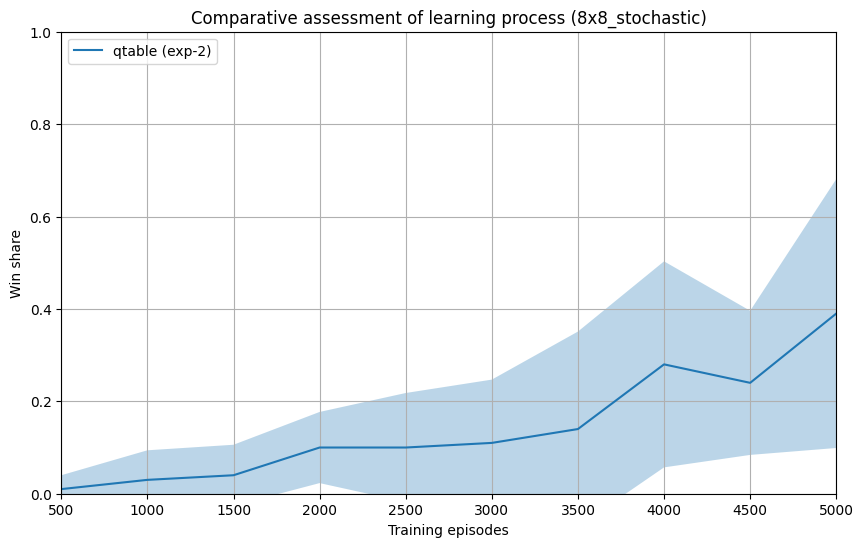

In [67]:
scenario_name = exp_params['scenario_name']
exp_ids = {
    exp_params['algorithm_name']: [exp_params['exp_id']]
}

display_validation_plot(scenarios_dir, scenario_name, exp_ids)

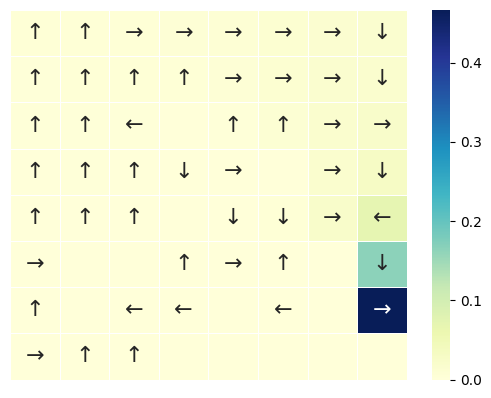

In [68]:
qtable_agent.display_q_table()

### <a id='toc1_4_3_'></a>[Оценка агента](#toc0_)

In [69]:
train_eps_num = 3500

load_best_agent_for_train_step(train_eps_num,
                               exp_params['training']['iteration_count'],
                               exp_dirs['training'],
                               qtable_agent)

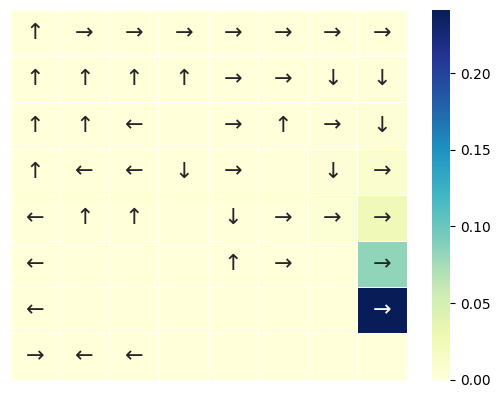

In [70]:
qtable_agent.display_q_table()

In [71]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)
evaluate_agent(env, qtable_agent, exp_params, exp_dirs)
env.close()

EPISODE # 1
Agent was defeated ☠️
Number of steps: 14
--------------------------------------------------
EPISODE # 2
Agent was defeated ☠️
Number of steps: 29
--------------------------------------------------
EPISODE # 3
Agent was defeated ☠️
Number of steps: 34
--------------------------------------------------


In [72]:
show_episode_records(exp_dirs['evaluation'])

## <a id='toc1_5_'></a>[Тестирование DynaQ-агента в стохастической среде](#toc0_)

In [73]:
MAP_SIZE = 8
STOCHASTIC_ENV = True

In [74]:
class DynaQAgent:

    def __init__(self, env, env_model_cls, params):
        self._env = env
        self._params = params
        self._epsilon = params['training']['epsilon']
        self._qtable = np.zeros((env.observation_space.n, env.action_space.n))
        self._model = env_model_cls(env.observation_space.n, env.action_space.n)
        self._action_arrow_map = { 0: '', 1: '←', 2: '↓', 3: '→', 4: '↑' }

    @property
    def name(self):
        return f"{self._params['algorithm_name']}_agent"

    @property
    def exploration_level(self):
        return self._epsilon


    def choose_action(self, state, mode='exploitation'):
        if mode == 'exploration':
          if np.random.rand() < self._epsilon:
              return self._env.action_space.sample()

        return np.argmax(self._qtable[state, :])


    def learn(self, state, action, next_state, reward):
        self._learn(state, action, next_state, reward)
        self._update_model(state, action, next_state, reward)
        self._planning(self._params['training']['planning_steps'])


    def decrease_exploration_level(self):
        if self._epsilon > self._params['training']['epsilon_min']:
            self._epsilon *= self._params['training']['epsilon_decay_rate']


    def display_q_table(self):
        self._prepare_q_table()


    def save_q_table_as_plot(self, eps_dir):
        q_table_plot = self._prepare_q_table()
        q_table_plot_path = os.path.join(eps_dir, 'qtable.png')
        q_table_plot.savefig(q_table_plot_path, bbox_inches='tight')
        plt.close(q_table_plot)


    def display_model(self):
        print(f'Transitions tabel:\n')
        self._model.display_transitions()
        print(f'\n\nRewards tabel:\n')
        self._model.display_rewards()


    def save_agent_state(self, state_dir):
        np.save(os.path.join(state_dir, 'qtable.npy'), self._qtable)
        np.save(os.path.join(state_dir, 'model_transitions.npy'), self._model.transitions)
        np.save(os.path.join(state_dir, 'model_rewards.npy'), self._model.rewards)


    def load_agent_state(self, state_dir):
        self._qtable = np.load(os.path.join(state_dir, 'qtable.npy'), allow_pickle=True)
        self._model.transitions = np.load(os.path.join(state_dir, 'model_transitions.npy'), allow_pickle=True)
        self._model.rewards = np.load(os.path.join(state_dir, 'model_rewards.npy'), allow_pickle=True)


    def _learn(self, state, action, next_state, reward):
        target = reward + self._params['training']['gamma'] * np.max(self._qtable[next_state, :])
        self._qtable[state, action] = self._qtable[state, action] + \
                                      self._params['training']['learning_rate'] * (target - self._qtable[state, action])


    def _update_model(self, state, action, next_state, reward):
        self._model.update(state, action, next_state, reward)


    def _planning(self, n_steps):
        for i in range(n_steps):
            state, action =  self._model.sample()
            next_state, reward = self._model.step(state, action)
            self._learn(state, action, next_state, reward)


    def _prepare_q_table(self):
        greedy_values = np.max(self._qtable, axis=1).reshape(MAP_SIZE, MAP_SIZE)
        greedy_actions = np.argmax(np.hstack((np.zeros((self._env.observation_space.n, 1)), self._qtable)), axis=1)
        greedy_actions_arrows = np.array(list(map(lambda x: '' if x == 0 else self._action_arrow_map[x], greedy_actions))).reshape(MAP_SIZE, MAP_SIZE)

        fig = plt.figure()
        sns.heatmap(greedy_values,
                    annot=greedy_actions_arrows,
                    annot_kws={"fontsize": 16},
                    fmt = '',
                    cmap="YlGnBu",
                    linewidths=.5)
        plt.axis('off')
        return fig


### <a id='toc1_5_1_'></a>[Реализация модели окружения (Домашнее задание!)](#toc0_)

Необходимо реализовать класс *StochasticEnvModel* для моделирования стохастической версии окружения, за основу можно взять класс *DeterministicEnvModel*.

In [75]:
from collections import defaultdict

class StochasticEnvModel:
    """
    Стохастическая табличная модель среды для Dyna-Q.

    Идея:
      - transitions[s, a] хранит частоты переходов в разные next_state
      - rewards[s, a] хранит статистику наград для переходов (s,a)->next_state
    """
    def __init__(self, n_states, n_actions):
        # Кол-во состояний и действий
        self.n_states = n_states
        self.n_actions = n_actions

        # Набор пар (state, action), для которых у нас уже есть хотя бы одно наблюдение
        self.completed_transitions = set()

        # Таблицы переходов и наград делаем "табличными", как в DeterministicEnvModel,
        # но т.к. среда стохастическая — в ячейках лежат словари со статистикой.
        self.transitions = np.empty((n_states, n_actions), dtype=object)
        self.rewards = np.empty((n_states, n_actions), dtype=object)

        for s in range(n_states):
            for a in range(n_actions):
                # transitions[s,a] : next_state -> count
                self.transitions[s, a] = defaultdict(int)
                # rewards[s,a] : next_state -> (reward_sum, count)
                self.rewards[s, a] = {}

    def update(self, state, action, next_state, reward):
        """
        Обновляем модель одним наблюдением (s, a, s', r).
        В отличие от детерминированной модели, здесь мы не "замораживаем" переход,
        а накапливаем статистику.
        """
        # Регистрируем, что (state, action) уже наблюдалась
        self.completed_transitions.add((state, action))

        # Обновляем частоты переходов
        self.transitions[state, action][next_state] += 1

        # Обновляем статистику наград для конкретного next_state
        r_sum, cnt = self.rewards[state, action].get(next_state, (0.0, 0))
        self.rewards[state, action][next_state] = (r_sum + float(reward), cnt + 1)



    def sample(self):
        """
        Сэмплируем случайную (state, action) из уже наблюдавшихся.
        По оформлению повторяет deterministic sample().
        """
        return random.choice(list(self.completed_transitions))
    
    
    def step(self, state, action):
        """
        Воображаемый шаг по модели:
          1) выбираем next_state согласно эмпирическому P_hat(s'|s,a)
          2) возвращаем ожидаемую награду для выбранного перехода
        """
        counts_dict = self.transitions[state, action]
        if not counts_dict:
            # Если данных нет — безопасный fallback
            return state, 0.0

        next_states = np.fromiter(counts_dict.keys(), dtype=int)
        counts = np.fromiter(counts_dict.values(), dtype=float)
        probs = counts / counts.sum()

        next_state = int(np.random.choice(next_states, p=probs))

        r_sum, cnt = self.rewards[state, action].get(next_state, (0.0, 0))
        reward = (r_sum / cnt) if cnt > 0 else 0.0

        return next_state, reward


    def display_transitions(self):
        """
        В детерминированной модели показывается матрица next_state.
        Здесь показываем в ячейках распределение вероятностей переходов.
        """
        def cell_to_str(d):
            if not d:
                return ""
            total = sum(d.values())
            probs = {k: round(v / total, 3) for k, v in d.items()}
            return str(probs)

        table = np.empty_like(self.transitions, dtype=object)
        for s in range(self.n_states):
            for a in range(self.n_actions):
                table[s, a] = cell_to_str(self.transitions[s, a])

        display(HTML(pd.DataFrame(table, columns=['L', 'D', 'R', 'U']).T.to_html()))



    def display_rewards(self):
        """
        В детерминированной модели показывается матрица reward.
        Здесь показываем ожидаемую награду E[r | s,a,s'] (в разрезе next_state).
        """
        def cell_to_str(d):
            if not d:
                return ""
            means = {ns: round(r_sum / cnt, 3) for ns, (r_sum, cnt) in d.items() if cnt > 0}
            return str(means)

        table = np.empty_like(self.rewards, dtype=object)
        for s in range(self.n_states):
            for a in range(self.n_actions):
                table[s, a] = cell_to_str(self.rewards[s, a])

        display(HTML(pd.DataFrame(table, columns=['L', 'D', 'R', 'U']).T.to_html()))





### <a id='toc1_5_2_'></a>[Параметры эксперимента](#toc0_)

In [76]:
exp_params = {
    'scenario_name': f'{MAP_SIZE}x{MAP_SIZE}_{"stochastic" if STOCHASTIC_ENV else "deterministic"}',
    'algorithm_name': 'dynaq',
    'exp_id': f'exp-3',
    'seed': 21,
    'training': {
        'iteration_count': 5,
        'episode_count': 5000,
        'learning_rate': 0.05,
        'gamma': 0.99,
        'epsilon': 1.0,
        'epsilon_min': 0.01,
        'epsilon_decay_rate': 0.99995,
        'planning_steps': 30
    },
    'validation': {
        'validate_agent_every_n_eps': 500,
        'episode_count': 10
    },
    'evaluation': {
        'episode_count': 3
    }
}

exp_dirs = create_exp_dirs(scenarios_dir, exp_params)
save_exp_params(exp_params, exp_dirs['exp'])

### <a id='toc1_5_3_'></a>[Обучение агента](#toc0_)

In [77]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)

for iter_num in range(1, exp_params['training']['iteration_count']+1):
    print(f'TRAINING ITERATION # {iter_num}\n')
    dynaq_agent = DynaQAgent(env, StochasticEnvModel, exp_params)
    train_agent(env, dynaq_agent, exp_params, exp_dirs, enable_eps_recording=True)
    if iter_num != exp_params['training']['iteration_count']:
        clear_output()

env.close()

TRAINING ITERATION # 5

EPISODE # 500 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 100.0
Aget exploration level (epsilon): 0.975
--------------------------------------------------
EPISODE # 1000 / 5000
Win share (10 eps): 0.1
Avg step count (10 eps): 64.9
Aget exploration level (epsilon): 0.951
--------------------------------------------------
EPISODE # 1500 / 5000
Win share (10 eps): 0.2
Avg step count (10 eps): 80.7
Aget exploration level (epsilon): 0.928
--------------------------------------------------
EPISODE # 2000 / 5000
Win share (10 eps): 0.3
Avg step count (10 eps): 83.1
Aget exploration level (epsilon): 0.905
--------------------------------------------------
EPISODE # 2500 / 5000
Win share (10 eps): 0.3
Avg step count (10 eps): 77.4
Aget exploration level (epsilon): 0.882
--------------------------------------------------
EPISODE # 3000 / 5000
Win share (10 eps): 0.7
Avg step count (10 eps): 64.5
Aget exploration level (epsilon): 0.861
-------------------------

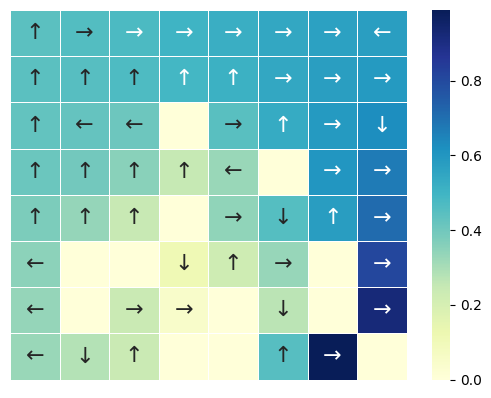

In [78]:
dynaq_agent.display_q_table()

In [79]:
dynaq_agent.display_model()

Transitions tabel:



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
L,"{8: 0.337, 0: 0.663}","{0: 0.353, 1: 0.329, 9: 0.318}","{1: 0.321, 2: 0.346, 10: 0.333}","{3: 0.344, 2: 0.322, 11: 0.334}","{12: 0.345, 4: 0.315, 3: 0.34}","{13: 0.322, 5: 0.323, 4: 0.356}","{6: 0.311, 5: 0.346, 14: 0.343}","{6: 0.333, 15: 0.371, 7: 0.296}","{16: 0.336, 8: 0.329, 0: 0.335}","{1: 0.319, 17: 0.333, 8: 0.348}","{18: 0.311, 2: 0.349, 9: 0.339}","{19: 0.36, 3: 0.318, 10: 0.321}","{4: 0.348, 11: 0.303, 20: 0.349}","{12: 0.316, 5: 0.318, 21: 0.367}","{13: 0.331, 6: 0.318, 22: 0.351}","{23: 0.346, 14: 0.367, 7: 0.287}","{8: 0.341, 24: 0.324, 16: 0.336}","{25: 0.317, 9: 0.354, 16: 0.33}","{17: 0.349, 10: 0.333, 26: 0.319}",,"{28: 0.352, 12: 0.34, 19: 0.309}","{20: 0.304, 13: 0.349, 29: 0.346}","{14: 0.334, 21: 0.385, 30: 0.281}","{31: 0.347, 15: 0.324, 22: 0.33}","{16: 0.342, 32: 0.357, 24: 0.3}","{17: 0.329, 33: 0.34, 24: 0.331}","{34: 0.349, 18: 0.297, 25: 0.353}","{35: 0.307, 26: 0.344, 19: 0.349}","{36: 0.376, 27: 0.327, 20: 0.298}",,"{38: 0.304, 22: 0.357, 29: 0.339}","{30: 0.385, 23: 0.32, 39: 0.295}","{32: 0.336, 24: 0.364, 40: 0.3}","{41: 0.32, 32: 0.334, 25: 0.346}","{26: 0.347, 42: 0.316, 33: 0.337}",,"{28: 0.429, 35: 0.333, 44: 0.238}","{36: 0.5, 45: 0.312, 29: 0.188}","{37: 0.282, 46: 0.521, 30: 0.197}","{31: 0.364, 47: 0.336, 38: 0.3}","{40: 0.302, 32: 0.333, 48: 0.364}",,,"{35: 0.333, 42: 0.333, 51: 0.333}","{43: 0.333, 36: 0.333, 52: 0.333}","{53: 0.333, 37: 0.2, 44: 0.467}",,"{46: 0.325, 55: 0.4, 39: 0.275}","{56: 0.367, 48: 0.28, 40: 0.353}",,,{59: 1.0},,,,"{63: 0.375, 47: 0.438, 54: 0.188}","{48: 0.336, 56: 0.664}","{56: 0.367, 49: 0.233, 57: 0.4}","{50: 0.5, 58: 0.5}",,{59: 1.0},,{54: 1.0},
D,"{0: 0.327, 1: 0.337, 8: 0.336}","{9: 0.335, 0: 0.328, 2: 0.337}","{3: 0.349, 10: 0.322, 1: 0.329}","{11: 0.35, 4: 0.332, 2: 0.319}","{5: 0.342, 3: 0.325, 12: 0.334}","{4: 0.319, 13: 0.315, 6: 0.366}","{14: 0.359, 7: 0.321, 5: 0.321}","{15: 0.329, 7: 0.32, 6: 0.351}","{8: 0.344, 9: 0.33, 16: 0.326}","{8: 0.327, 17: 0.346, 10: 0.327}","{9: 0.322, 18: 0.338, 11: 0.34}","{10: 0.354, 12: 0.327, 19: 0.319}","{11: 0.359, 20: 0.323, 13: 0.318}","{14: 0.357, 12: 0.323, 21: 0.321}","{15: 0.346, 22: 0.327, 13: 0.327}","{15: 0.3, 14: 0.368, 23: 0.333}","{24: 0.338, 16: 0.344, 17: 0.318}","{16: 0.346, 18: 0.309, 25: 0.344}","{17: 0.315, 26: 0.338, 19: 0.348}",,"{19: 0.313, 28: 0.374, 21: 0.313}","{29: 0.367, 20: 0.317, 22: 0.317}","{30: 0.301, 23: 0.31, 21: 0.389}","{22: 0.34, 23: 0.36, 31: 0.3}","{24: 0.342, 25: 0.319, 32: 0.339}","{33: 0.327, 24: 0.327, 26: 0.346}","{27: 0.343, 34: 0.317, 25: 0.34}","{28: 0.376, 26: 0.29, 35: 0.333}","{29: 0.313, 27: 0.276, 36: 0.41}",,"{31: 0.394, 29: 0.342, 38: 0.265}","{30: 0.362, 39: 0.315, 31: 0.323}","{32: 0.374, 40: 0.309, 33: 0.317}","{32: 0.351, 41: 0.281, 34: 0.368}","{33: 0.368, 42: 0.312, 35: 0.32}",,"{44: 0.286, 35: 0.429, 37: 0.286}","{36: 0.309, 38: 0.4, 45: 0.291}","{39: 0.333, 46: 0.397, 37: 0.269}","{47: 0.349, 38: 0.286, 39: 0.365}","{41: 0.335, 40: 0.369, 48: 0.296}",,,"{44: 0.4, 51: 0.4, 42: 0.2}","{43: 0.429, 52: 0.286, 45: 0.286}","{44: 0.375, 53: 0.125, 46: 0.5}",,"{55: 0.314, 47: 0.353, 46: 0.333}","{56: 0.373, 48: 0.293, 49: 0.333}",,{49: 1.0},{59: 1.0},,"{61: 0.5, 54: 0.5}",,"{54: 0.222, 55: 0.444, 63: 0.333}","{56: 0.75, 57: 0.25}","{57: 0.3, 56: 0.4, 58: 0.3}","{58: 0.667, 57: 0.167, 59: 0.167}",,,,{62: 1.0},
R,"{0: 0.338, 1: 0.321, 8: 0.341}","{2: 0.328, 9: 0.332, 1: 0.34}","{10: 0.336, 2: 0.331, 3: 0.333}","{11: 0.337, 4: 0.351, 3: 0.312}","{5: 0.347, 4: 0.328, 12: 0.325}","{5: 0.341, 6: 0.337, 13: 0.322}","{7: 0.318, 6: 0.321, 14: 0.361}","{7: 0.704, 15: 0.296}","{16: 0.337, 0: 0.328, 9: 0.335}","{1: 0.313, 17: 0.328, 10: 0.359}","{18: 0.344, 11: 0.335, 2: 0.321}","{19: 0.355, 12: 0.325, 3: 0.321}","{4: 0.33, 13: 0.327, 20: 0.343}","{21: 0.31, 5: 0.368, 14: 0.322}","{22: 0.3



Rewards tabel:



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
L,"{8: 0.0, 0: 0.0}","{0: 0.0, 1: 0.0, 9: 0.0}","{1: 0.0, 2: 0.0, 10: 0.0}","{3: 0.0, 2: 0.0, 11: 0.0}","{12: 0.0, 4: 0.0, 3: 0.0}","{13: 0.0, 5: 0.0, 4: 0.0}","{6: 0.0, 5: 0.0, 14: 0.0}","{6: 0.0, 15: 0.0, 7: 0.0}","{16: 0.0, 8: 0.0, 0: 0.0}","{1: 0.0, 17: 0.0, 8: 0.0}","{18: 0.0, 2: 0.0, 9: 0.0}","{19: 0.0, 3: 0.0, 10: 0.0}","{4: 0.0, 11: 0.0, 20: 0.0}","{12: 0.0, 5: 0.0, 21: 0.0}","{13: 0.0, 6: 0.0, 22: 0.0}","{23: 0.0, 14: 0.0, 7: 0.0}","{8: 0.0, 24: 0.0, 16: 0.0}","{25: 0.0, 9: 0.0, 16: 0.0}","{17: 0.0, 10: 0.0, 26: 0.0}",,"{28: 0.0, 12: 0.0, 19: 0.0}","{20: 0.0, 13: 0.0, 29: 0.0}","{14: 0.0, 21: 0.0, 30: 0.0}","{31: 0.0, 15: 0.0, 22: 0.0}","{16: 0.0, 32: 0.0, 24: 0.0}","{17: 0.0, 33: 0.0, 24: 0.0}","{34: 0.0, 18: 0.0, 25: 0.0}","{35: 0.0, 26: 0.0, 19: 0.0}","{36: 0.0, 27: 0.0, 20: 0.0}",,"{38: 0.0, 22: 0.0, 29: 0.0}","{30: 0.0, 23: 0.0, 39: 0.0}","{32: 0.0, 24: 0.0, 40: 0.0}","{41: 0.0, 32: 0.0, 25: 0.0}","{26: 0.0, 42: 0.0, 33: 0.0}",,"{28: 0.0, 35: 0.0, 44: 0.0}","{36: 0.0, 45: 0.0, 29: 0.0}","{37: 0.0, 46: 0.0, 30: 0.0}","{31: 0.0, 47: 0.0, 38: 0.0}","{40: 0.0, 32: 0.0, 48: 0.0}",,,"{35: 0.0, 42: 0.0, 51: 0.0}","{43: 0.0, 36: 0.0, 52: 0.0}","{53: 0.0, 37: 0.0, 44: 0.0}",,"{46: 0.0, 55: 0.0, 39: 0.0}","{56: 0.0, 48: 0.0, 40: 0.0}",,,{59: 0.0},,,,"{63: 1.0, 47: 0.0, 54: 0.0}","{48: 0.0, 56: 0.0}","{56: 0.0, 49: 0.0, 57: 0.0}","{50: 0.0, 58: 0.0}",,{59: 0.0},,{54: 0.0},
D,"{0: 0.0, 1: 0.0, 8: 0.0}","{9: 0.0, 0: 0.0, 2: 0.0}","{3: 0.0, 10: 0.0, 1: 0.0}","{11: 0.0, 4: 0.0, 2: 0.0}","{5: 0.0, 3: 0.0, 12: 0.0}","{4: 0.0, 13: 0.0, 6: 0.0}","{14: 0.0, 7: 0.0, 5: 0.0}","{15: 0.0, 7: 0.0, 6: 0.0}","{8: 0.0, 9: 0.0, 16: 0.0}","{8: 0.0, 17: 0.0, 10: 0.0}","{9: 0.0, 18: 0.0, 11: 0.0}","{10: 0.0, 12: 0.0, 19: 0.0}","{11: 0.0, 20: 0.0, 13: 0.0}","{14: 0.0, 12: 0.0, 21: 0.0}","{15: 0.0, 22: 0.0, 13: 0.0}","{15: 0.0, 14: 0.0, 23: 0.0}","{24: 0.0, 16: 0.0, 17: 0.0}","{16: 0.0, 18: 0.0, 25: 0.0}","{17: 0.0, 26: 0.0, 19: 0.0}",,"{19: 0.0, 28: 0.0, 21: 0.0}","{29: 0.0, 20: 0.0, 22: 0.0}","{30: 0.0, 23: 0.0, 21: 0.0}","{22: 0.0, 23: 0.0, 31: 0.0}","{24: 0.0, 25: 0.0, 32: 0.0}","{33: 0.0, 24: 0.0, 26: 0.0}","{27: 0.0, 34: 0.0, 25: 0.0}","{28: 0.0, 26: 0.0, 35: 0.0}","{29: 0.0, 27: 0.0, 36: 0.0}",,"{31: 0.0, 29: 0.0, 38: 0.0}","{30: 0.0, 39: 0.0, 31: 0.0}","{32: 0.0, 40: 0.0, 33: 0.0}","{32: 0.0, 41: 0.0, 34: 0.0}","{33: 0.0, 42: 0.0, 35: 0.0}",,"{44: 0.0, 35: 0.0, 37: 0.0}","{36: 0.0, 38: 0.0, 45: 0.0}","{39: 0.0, 46: 0.0, 37: 0.0}","{47: 0.0, 38: 0.0, 39: 0.0}","{41: 0.0, 40: 0.0, 48: 0.0}",,,"{44: 0.0, 51: 0.0, 42: 0.0}","{43: 0.0, 52: 0.0, 45: 0.0}","{44: 0.0, 53: 0.0, 46: 0.0}",,"{55: 0.0, 47: 0.0, 46: 0.0}","{56: 0.0, 48: 0.0, 49: 0.0}",,{49: 0.0},{59: 0.0},,"{61: 0.0, 54: 0.0}",,"{54: 0.0, 55: 0.0, 63: 1.0}","{56: 0.0, 57: 0.0}","{57: 0.0, 56: 0.0, 58: 0.0}","{58: 0.0, 57: 0.0, 59: 0.0}",,,,{62: 0.0},
R,"{0: 0.0, 1: 0.0, 8: 0.0}","{2: 0.0, 9: 0.0, 1: 0.0}","{10: 0.0, 2: 0.0, 3: 0.0}","{11: 0.0, 4: 0.0, 3: 0.0}","{5: 0.0, 4: 0.0, 12: 0.0}","{5: 0.0, 6: 0.0, 13: 0.0}","{7: 0.0, 6: 0.0, 14: 0.0}","{7: 0.0, 15: 0.0}","{16: 0.0, 0: 0.0, 9: 0.0}","{1: 0.0, 17: 0.0, 10: 0.0}","{18: 0.0, 11: 0.0, 2: 0.0}","{19: 0.0, 12: 0.0, 3: 0.0}","{4: 0.0, 13: 0.0, 20: 0.0}","{21: 0.0, 5: 0.0, 14: 0.0}","{22: 0.0, 6: 0.0, 15: 0.0}","{7: 0.0, 15: 0.0, 23: 0.0}","{8: 0.0, 24: 0.0, 17: 0.0}","{9: 0.0, 25: 0.0, 18: 0.0}","{19: 0.0, 26: 0.0, 10: 0.0}",,"{12: 0.0, 28: 0.0, 21: 0.0}","{29: 0.0, 22: 0.0, 13: 0.0}","{14: 0.0, 30: 0.0, 23: 0.0}","{15: 0.0, 23: 0.0, 31: 0.0}","{16: 0.0, 25: 0.0, 32: 0.0}","{33: 0.0, 26: 0.0, 17: 0.0}","{27: 0.0, 34: 0.0, 18: 0.0}","{35: 0.0, 28: 0.0, 19: 0.0}","{20: 0.0, 29: 0.0, 36: 0.0}",,"{22: 0.0, 31: 0.0, 38: 0.0}","{31: 0.0, 23: 0.0, 39: 0.0}","{24: 0.0, 33: 0.0, 40: 0.0}","{25: 0.0, 41: 0.0, 34: 0.0}","{26: 0.0, 42: 0.0, 35: 0.0}",,"{28: 0.0, 37: 

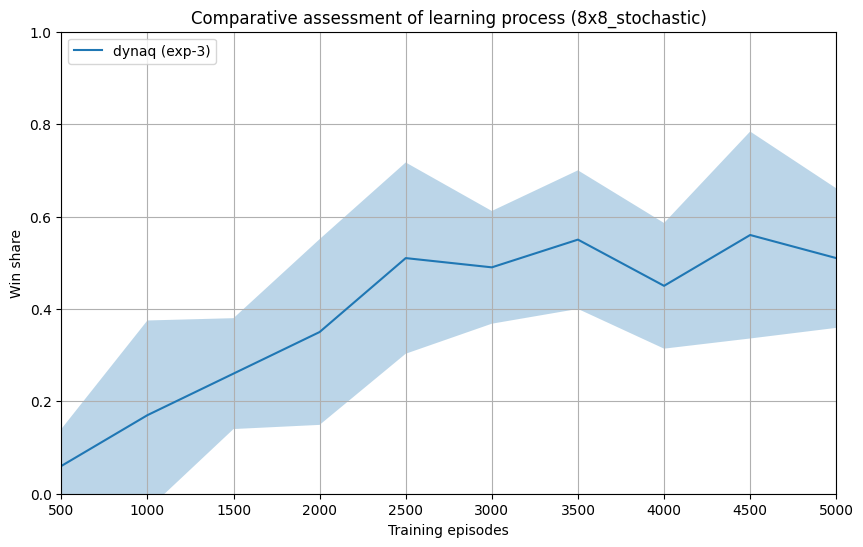

In [80]:
scenario_name = exp_params['scenario_name']
exp_ids = {
    exp_params['algorithm_name']: [exp_params['exp_id']]
}

display_validation_plot(scenarios_dir, scenario_name, exp_ids)

### <a id='toc1_5_4_'></a>[Оценка агента](#toc0_)

In [81]:
train_eps_num = 4000

load_best_agent_for_train_step(train_eps_num,
                               exp_params['training']['iteration_count'],
                               exp_dirs['training'],
                               dynaq_agent)

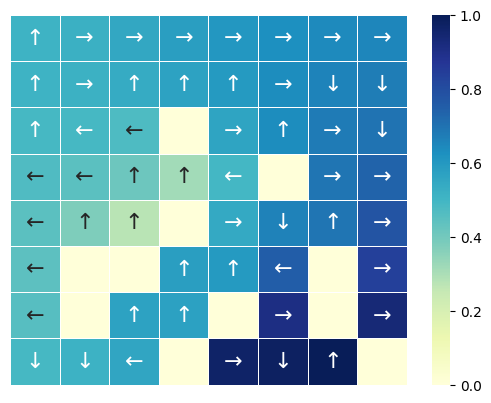

In [82]:
dynaq_agent.display_q_table()

In [83]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)
evaluate_agent(env, dynaq_agent, exp_params, exp_dirs)
env.close()

EPISODE # 1
Agent was defeated ☠️
Number of steps: 59
--------------------------------------------------
EPISODE # 2
Agent reached the Goal 🏆
Number of steps: 61
--------------------------------------------------
EPISODE # 3
Agent was defeated ☠️
Number of steps: 50
--------------------------------------------------


In [84]:
show_episode_records(exp_dirs['evaluation'])

## <a id='toc1_6_'></a>[Сравнение эффективности процесса обучения](#toc0_)

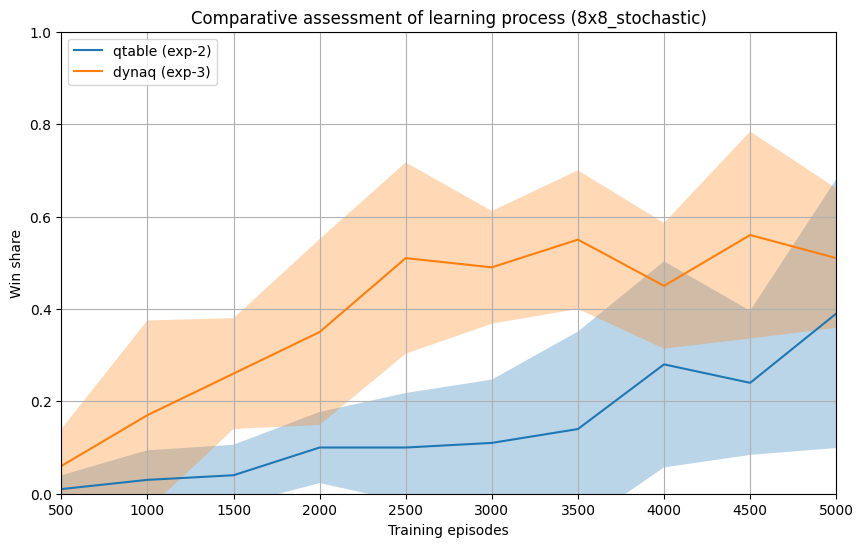

In [85]:
scenario_name = '8x8_stochastic'
exp_ids = {
    'qtable': ['exp-2'],
    'dynaq': ['exp-3']
}

display_validation_plot(scenarios_dir, scenario_name, exp_ids)

## <a id='toc1_7_'></a>[Выводы](#toc0_)

Как можно видеть из графиков добавление модели мира увеличивает скорость и качество обучения и  мы быстрее выходим на плато.